# Sequence data and tensor shapes

**Learning objective:** Read, construct and reason about `(batch, time, features)` tensors before building recurrent layers.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:13:07.439424: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974787.454475    2736 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974787.458785    2736 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:13:09.102030: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## The three axes
        A dense tabular batch is commonly `(batch, features)`. A sequence adds time: `(batch, time, features)`. A batch of 4 sensor histories, each 6 hours long with 3 measurements per hour, therefore has shape `(4, 6, 3)`.


In [2]:
x = np.arange(4*6*3, dtype=np.float32).reshape(4,6,3)
print("shape:", x.shape)
print("first example:\n", x[0])
print("timestep 2 across batch:\n", x[:,2,:])


shape: (4, 6, 3)
first example:
 [[ 0.  1.  2.]
 [ 3.  4.  5.]
 [ 6.  7.  8.]
 [ 9. 10. 11.]
 [12. 13. 14.]
 [15. 16. 17.]]
timestep 2 across batch:
 [[ 6.  7.  8.]
 [24. 25. 26.]
 [42. 43. 44.]
 [60. 61. 62.]]


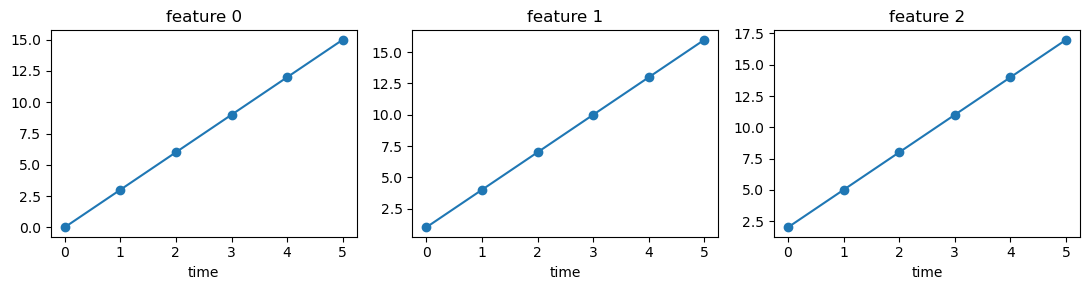

In [3]:
fig, axes = plt.subplots(1,3, figsize=(11,3))
for feature, ax in enumerate(axes):
    ax.plot(x[0,:,feature], marker="o"); ax.set_title(f"feature {feature}"); ax.set_xlabel("time")
plt.tight_layout(); plt.show()


**Interpretation:** time is not interchangeable with the feature axis. Recurrent layers move along the time axis while observing the feature vector at each step.
